In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from numpy.polynomial.polynomial import Polynomial
import numpy as np
import ast

In [2]:
df_results_6_nodes_just_positive = pd.read_csv("/Users/reyesfer/Desktop/qDriftExtraPolation/src/qdrift_ising_model_6_nodes_2025-07-17.csv")

Group: (1,)
Exact Eigenvalue: 1.2806248474865685
Alpha: 1.7999999999999998
Num Ancilla: 10
Polynomial Coefficients: [1.31351149e+00 1.12917602e-16 3.25665618e-01]
Y-intercept at x = 0: 1.3135114873752194
Correct eigenvalue: 1.2806248474865685
Error ratio: 0.025680151336432547


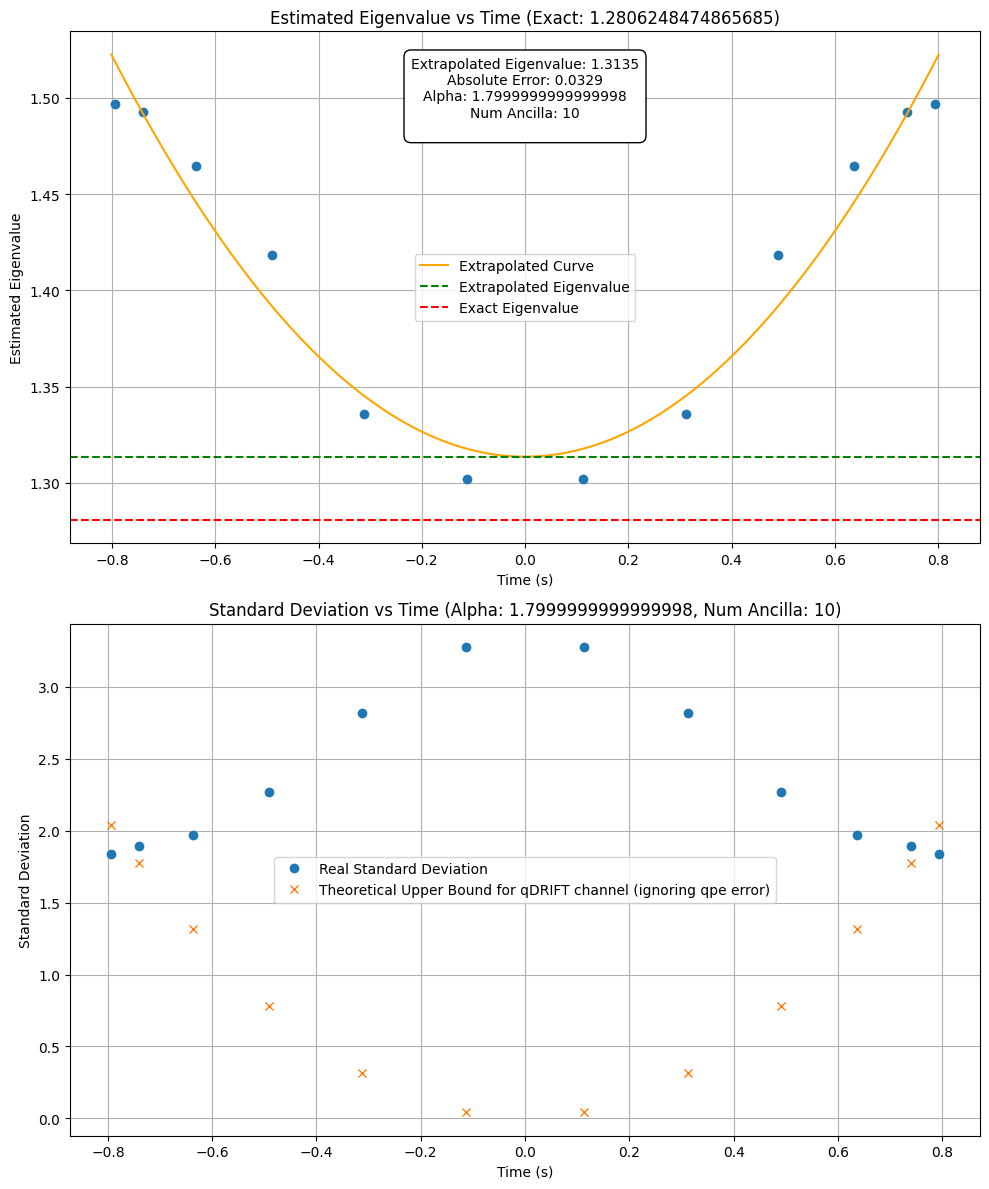

Group: (2,)
Exact Eigenvalue: 1.2806248474865685
Alpha: 1.7999999999999998
Num Ancilla: 10
Polynomial Coefficients: [1.28486207e+00 8.46882015e-17 2.47569229e-02]
Y-intercept at x = 0: 1.2848620687868693
Correct eigenvalue: 1.2806248474865685
Error ratio: 0.003308713952112536


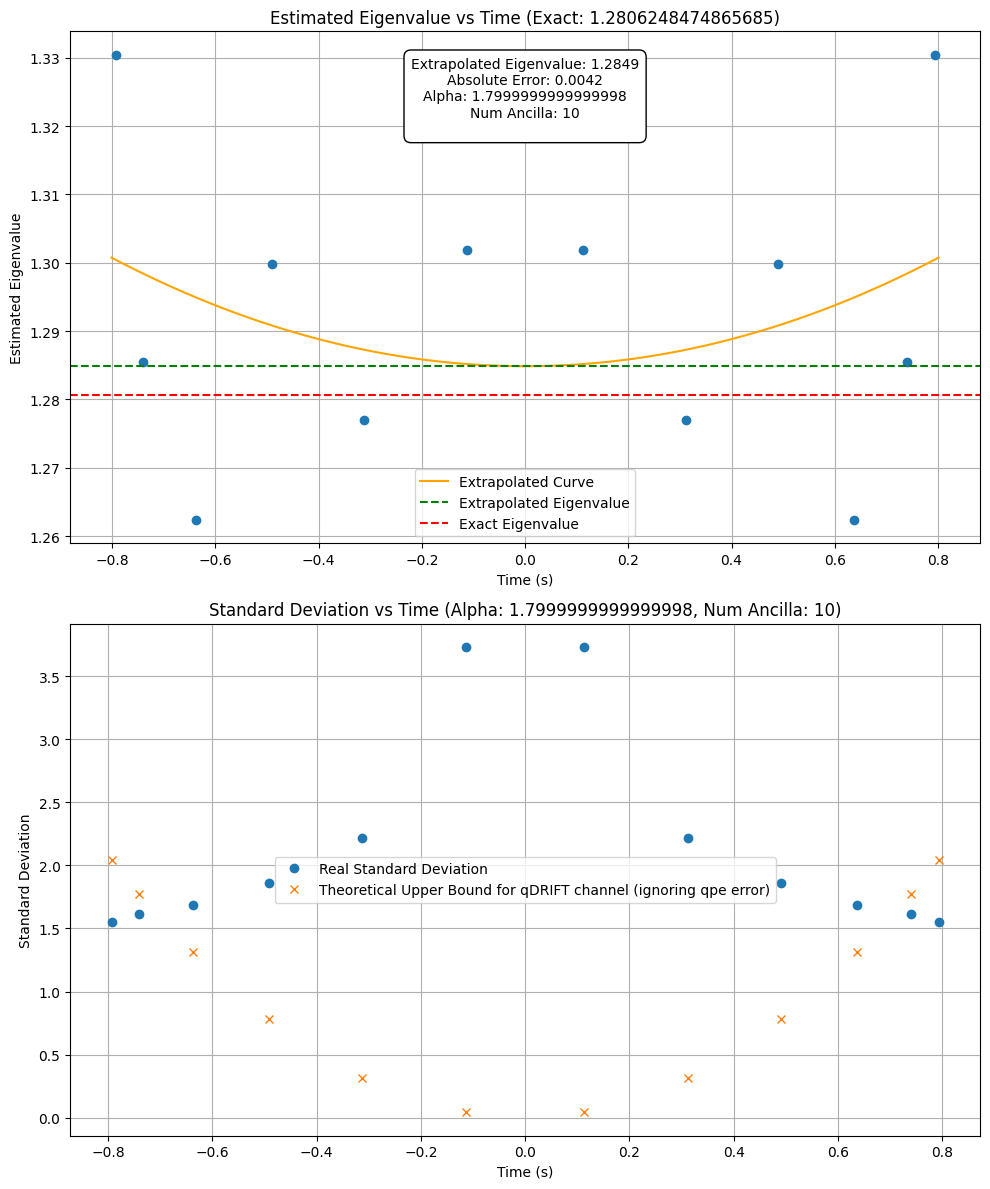

Group: (10,)
Exact Eigenvalue: 1.2806248474865685
Alpha: 1.7999999999999998
Num Ancilla: 10
Polynomial Coefficients: [ 1.29207216e+00  2.39949904e-16 -2.42649757e-02]
Y-intercept at x = 0: 1.2920721645364683
Correct eigenvalue: 1.2806248474865685
Error ratio: 0.008938852836072226


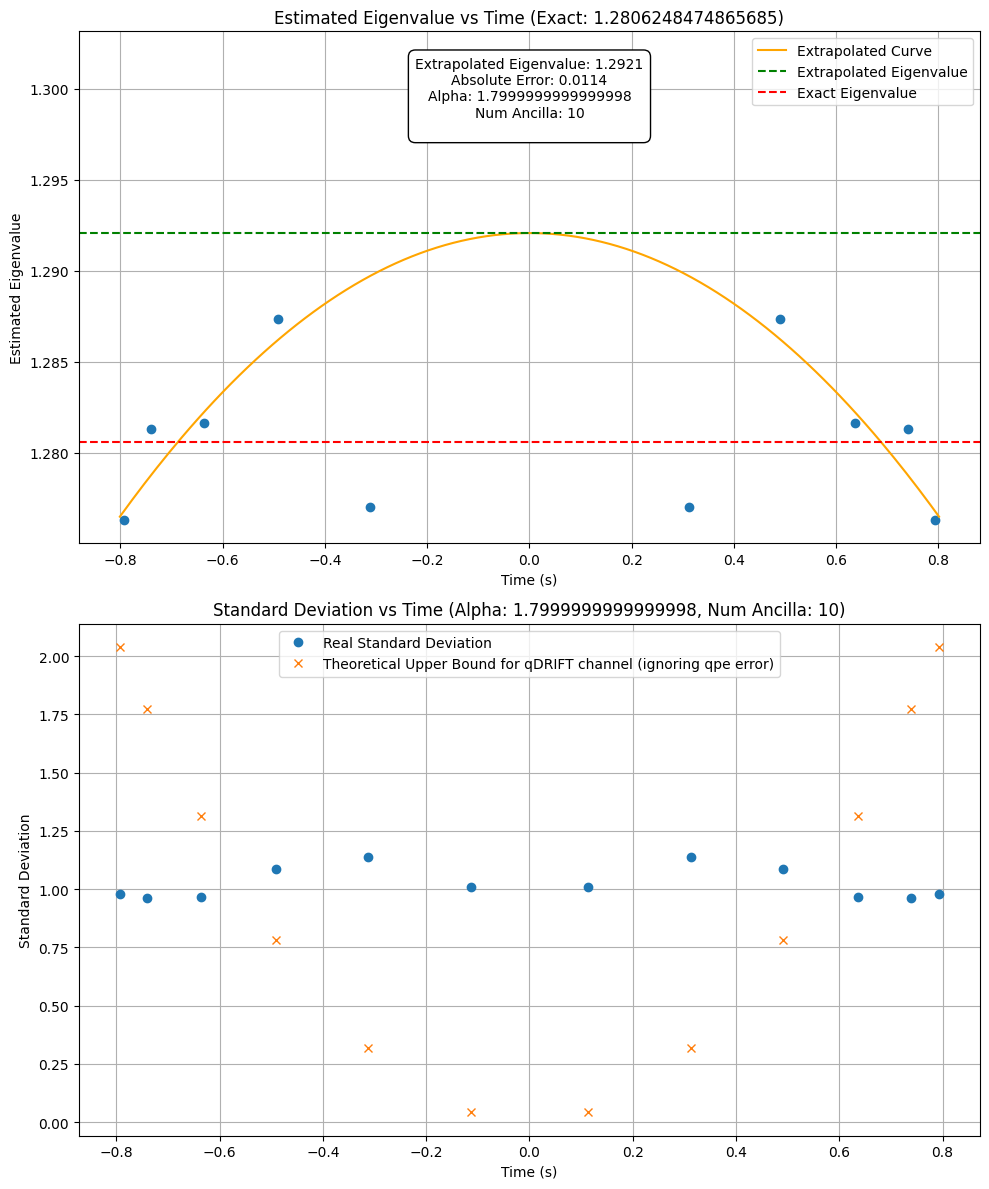

In [15]:


def plot_chebyshev_extrapolation_results(df, groupbys, show_stdevs):
    for group_name, group in df.groupby(groupbys):
        print(f"Group: {group_name}")
        exact_eigenvalue = ast.literal_eval(group["Exact Eigenvalue"].iloc[0]) if isinstance(group["Exact Eigenvalue"].iloc[0], str) else group["Exact Eigenvalue"].iloc[0]
        if isinstance(exact_eigenvalue, complex):
            exact_eigenvalue = exact_eigenvalue.real
        print(f"Exact Eigenvalue: {exact_eigenvalue}")
        alpha = group["Alpha"].iloc[0]
        print(f"Alpha: {alpha}")
        num_ancilla = group["Num Ancilla"].iloc[0]
        print(f"Num Ancilla: {num_ancilla}")

        # mirror the results across the y-axis to duplicate the data (physics math moment)
        df_mirror = group.copy()
        df_mirror["Time"] = -df_mirror["Time"]
        group = pd.concat([group, df_mirror])

        if not show_stdevs:

            plt.figure(figsize=(10, 6))
            plt.plot(group["Time"], group["Estimated Eigenvalue"], marker='o', linestyle='None')
            
            # fit a polynomial to the data
            coeffs = Polynomial.fit(group["Time"], group["Estimated Eigenvalue"], 2).convert().coef
            print(f"Polynomial Coefficients: {coeffs}")
            
            y_intercept = coeffs[0]
            print(f"Y-intercept at x = 0: {y_intercept}")
            print(f"Correct eigenvalue: {exact_eigenvalue}")
            print(f"Error ratio: {abs(exact_eigenvalue - y_intercept) / exact_eigenvalue}")

            # Extrapolation range (extend 20% beyond the last x)
            x_extra = np.linspace(group["Time"].min() * 1.01, group["Time"].max() * 1.01, 200)
            y_extra = sum(c * x_extra**i for i, c in enumerate(coeffs))
            
            plt.plot(x_extra, y_extra, label='Extrapolated Curve', color='orange')
            plt.axhline(y=y_intercept, color='g', linestyle='--', label='Extrapolated Eigenvalue')
            plt.axhline(y=exact_eigenvalue, color='r', linestyle='--', label='Exact Eigenvalue')
            
            plt.xlabel("Time (s)")
            plt.ylabel("Estimated Eigenvalue")
            plt.title(f"Estimated Eigenvalue vs Time (Exact: {exact_eigenvalue})")
            
            # add textbox info about the extrapolated eigenvalue 
            stats_text = (f"Extrapolated Eigenvalue: {y_intercept:.4f}\n"
                        f"Absolute Error: {abs(exact_eigenvalue - y_intercept):.4f}\n"
                        f"Alpha: {alpha}\n"
                        f"Num Ancilla: {num_ancilla}\n")
            plt.text(0.5, 0.95, stats_text, ha='center', va='top', transform=plt.gca().transAxes,
                    bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'))
            plt.grid(True)
            plt.tight_layout()
            plt.legend()
            plt.show()
        else:
            # plot a grid with two subplots: one for the estimated eigenvalue and one for the standard deviation
            fig, axs = plt.subplots(2, 1, figsize=(10, 12))
            axs[0].plot(group["Time"], group["Estimated Eigenvalue"], marker='o', linestyle='None')
            # fit a polynomial to the data
            coeffs = Polynomial.fit(group["Time"], group["Estimated Eigenvalue"], 2).convert().coef 
            print(f"Polynomial Coefficients: {coeffs}")
            y_intercept = coeffs[0]
            print(f"Y-intercept at x = 0: {y_intercept}")
            print(f"Correct eigenvalue: {exact_eigenvalue}")
            print(f"Error ratio: {abs(exact_eigenvalue - y_intercept) / exact_eigenvalue}")
            # Extrapolation range (extend 20% beyond the last x)
            x_extra = np.linspace(group["Time"].min() * 1.01, group["Time"].max() * 1.01, 200)
            y_extra = sum(c * x_extra**i for i, c in enumerate(coeffs
            ))
            axs[0].plot(x_extra, y_extra, label='Extrapolated Curve', color='orange')
            axs[0].axhline(y=y_intercept, color='g', linestyle='--', label='Extrapolated Eigenvalue')
            axs[0].axhline(y=exact_eigenvalue, color='r', linestyle='--', label='Exact Eigenvalue')
            axs[0].set_xlabel("Time (s)")
            axs[0].set_ylabel("Estimated Eigenvalue")
            axs[0].set_title(f"Estimated Eigenvalue vs Time (Exact: {exact_eigenvalue})")
            # add textbox info about the extrapolated eigenvalue
            stats_text = (f"Extrapolated Eigenvalue: {y_intercept:.4f}\n"
                        f"Absolute Error: {abs(exact_eigenvalue - y_intercept):.4f}\n"
                        f"Alpha: {alpha}\n"
                        f"Num Ancilla: {num_ancilla}\n")
            axs[0].text(0.5, 0.95, stats_text, ha='center', va='top', transform=axs[0].transAxes,
                        bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'))
            axs[0].grid(True)
            axs[0].legend()

            # plot the standard deviation
            # theoretical upper bound for standard deviation
            stdev_theoretical_upper_bound = (alpha ** 2 * group["Time"] ** 2)
            axs[1].plot(group["Time"], group["stdev energy"], marker='o', linestyle='None', label='Real Standard Deviation')
            axs[1].plot(group["Time"], stdev_theoretical_upper_bound, marker='x', linestyle='None', label='Theoretical Upper Bound for qDRIFT channel (ignoring qpe error)')
            axs[1].set_xlabel("Time (s)")
            axs[1].set_ylabel("Standard Deviation")
            axs[1].set_title(f"Standard Deviation vs Time (Alpha: {alpha}, Num Ancilla: {num_ancilla})")
            axs[1].grid(True)
            axs[1].legend()
            plt.tight_layout()
            plt.show()
plot_chebyshev_extrapolation_results(df_results_6_nodes_just_positive, ["num segments per invocation"], show_stdevs=True)

Group: (100,)
Exact Eigenvalue: 1.2806248474865685
Alpha: 1.7999999999999998
Num Ancilla: 12
Polynomial Coefficients: [1.2064897  0.         1.83864097]
Y-intercept at x = 0: 1.2064896982760795
Correct eigenvalue: 1.2806248474865685
Error ratio: 0.057889825701875945


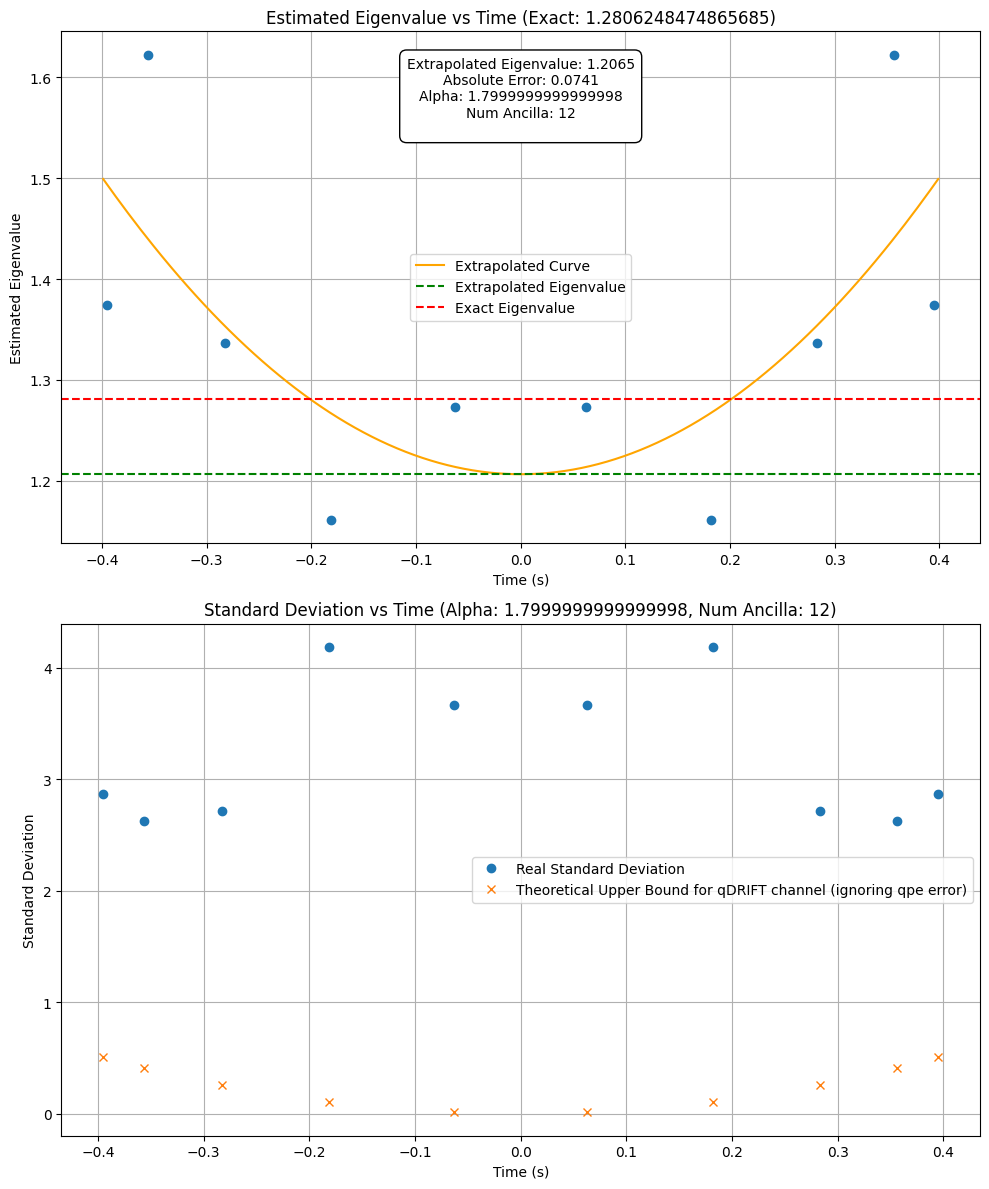

Group: (1000,)
Exact Eigenvalue: 1.2806248474865685
Alpha: 1.7999999999999998
Num Ancilla: 12
Polynomial Coefficients: [ 1.26999834e+00 -2.48236130e-16  6.04007212e-01]
Y-intercept at x = 0: 1.2699983375997463
Correct eigenvalue: 1.2806248474865685
Error ratio: 0.00829791012385739


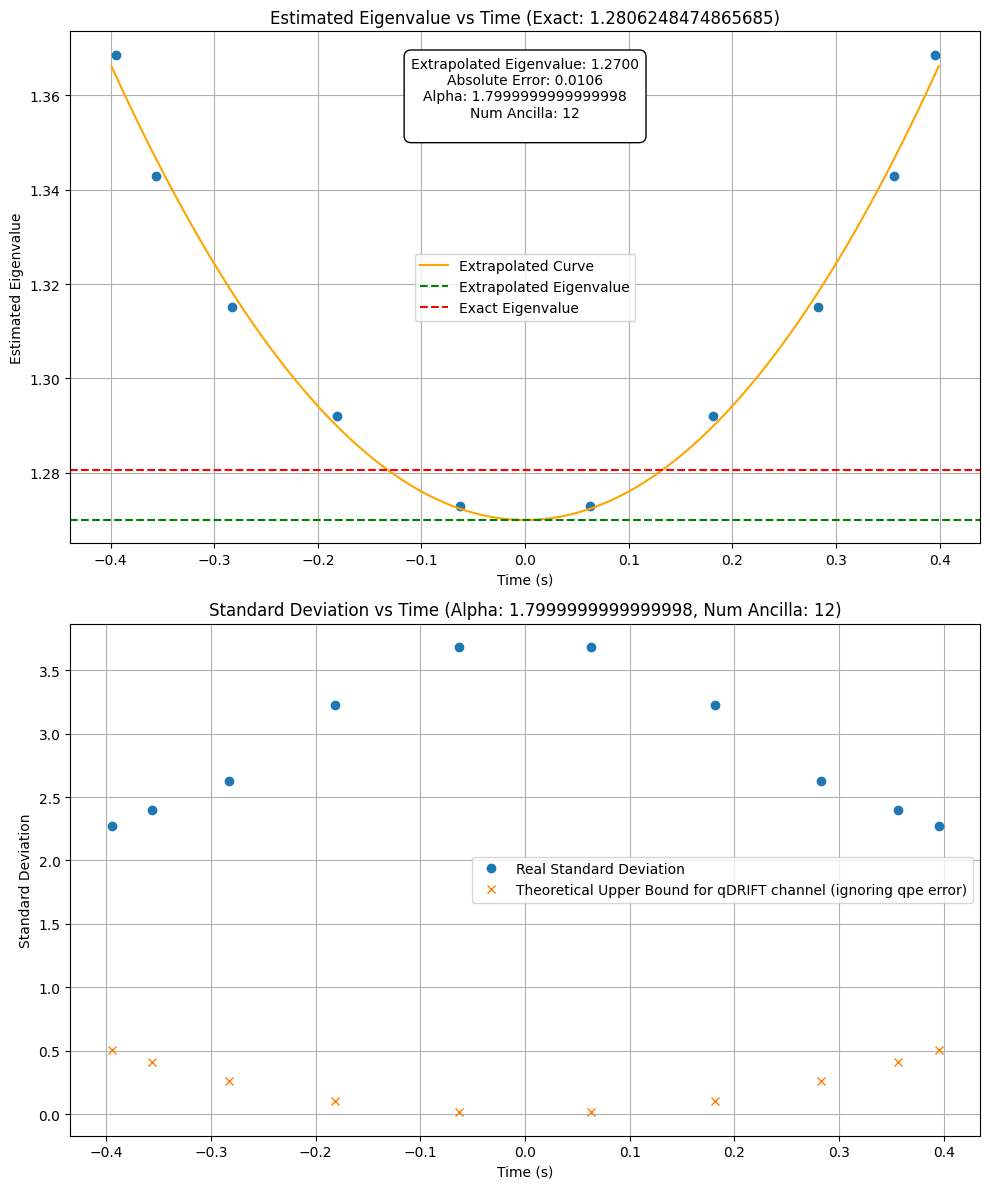

In [19]:
df_results_5_nodes_just_positive = pd.read_csv("/Users/reyesfer/Desktop/qDriftExtraPolation/src/parameter_sweep/qdrift_qpe_5_chebyshev_function_cache_2025-07-24.csv")
df_results_5_nodes_just_positive["Alpha"] = 1.7999999999999998  # assuming alpha is constant for this dataset
plot_chebyshev_extrapolation_results(df_results_5_nodes_just_positive, ["n_circuits"], show_stdevs=True)